This notebook create and use a new version of data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
sns.set_theme(style='darkgrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

%load_ext autoreload
%autoreload 2

In [2]:
raw_data = pd.read_csv("../data/processed/mhd_ch4_ml.csv")
raw_data.head()

/tmp/ipykernel_66254/1833448098.py:1: DtypeWarning: Columns (67) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data = pd.read_csv("../data/processed/mhd_ch4_ml.csv")


,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,label2,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,1,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,1,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,1,0.384554,NaN,NaN,0,1,0,0,0,0,NaN,NaN
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0,0.142279,NaN,NaN,0,1,0,0,0,0,NaN,NaN
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,1,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN



flag = B means good data
create new label as label3
Rl, R, C related features shouldn't be used ( reveal the future) and std feature
------------
create new dataset:
updated_v1
----------


In [3]:
data = raw_data.copy()
data.head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_raw,CH4_flag_ht_raw,CH4_flag_a_raw,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,label2,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,1,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,1,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,1,0.384554,NaN,NaN,0,1,0,0,0,0,NaN,NaN
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0,0.142279,NaN,NaN,0,1,0,0,0,0,NaN,NaN
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,,F,F,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,1,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN


In [4]:
# drop the feature duplicated and old labels
data = data.drop(columns =['CH4_flag_raw', 'CH4_flag_ht_raw', 'CH4_flag_a_raw', 'label2'])
data.head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,0.384554,NaN,NaN,0,1,0,0,0,0,NaN,NaN
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0.142279,NaN,NaN,0,1,0,0,0,0,NaN,NaN
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN


leave the CH4_flag_ht_bin, CH4_flag_a_bin and label1 but directly change it.
留下特徵但是重新改
B: 0 (good)

In [5]:
mapping={" ":0, 
          "x":1, 
          "*":1,
          "F":1, 
          "B":0, 
        }
data['CH4_flag_ht_bin'] = data['CH4_flag_ht'].map(mapping)
data['CH4_flag_a_bin'] = data['CH4_flag_a'].map(mapping)



In [6]:
data.isna().sum() # check if the flag contains Nan values

date                           0
time                           0
type                           1
sample                         0
standard                       0
port                           0
ht                             0
tmod                      112284
tamb                      112284
lab_temp                  817955
pflow                       2402
psamp                       2329
ploop                     817955
pamb                        2404
CH4_rt                      1590
CH4_w                       1590
CH4_ht                      1590
CH4_area                    1590
CH4_skew                    1590
CH4_start_time              1590
CH4_end_time                1590
CH4_start_level             1590
CH4_end_level               1590
CH4_Rl_ht                  51247
CH4_Rl_a                   49492
CH4_Rl                     58674
CH4_norm_ht                51247
CH4_norm_a                 51247
CH4_norm_w                 51247
CH4_R_ht                   51247
CH4_R_a   

In [7]:
data['label1'] = (
    (data['CH4_flag_ht_bin'] == 1)|
    (data['CH4_flag_a_bin'] == 1)
).astype(int)

In [8]:
data.head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,0.384554,NaN,NaN,0,1,0,0,0,0,NaN,NaN
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0.142279,NaN,NaN,0,1,0,0,0,0,NaN,NaN
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN


In [9]:
data[(data['CH4_flag_a']=='B')| (data['CH4_flag_ht']=='B')].head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal
84,940218,100,std,G-024,G-024,1,0,40.00,22.50,NaN,844.4,749.96,NaN,750.1,95.0,6.84,158732.0,1175833.0,1.10,83.4,129.0,39014.0,38749.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.714,NaN,1692.489,B,B,,,0,0,0,940218000100,1994-02-18 00:01:00,False,False,False,False,45.6,False,-265.0,0.134995,1994-02-17 23:21:00,2400.0,1,0,0,0,0,0,NaN,NaN
631,940225,172000,std,G-024,G-024,1,0,40.00,23.90,NaN,832.8,741.32,NaN,741.3,95.2,7.13,158582.0,1221129.0,1.04,83.2,129.6,27774.0,27805.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.931,NaN,1692.489,B,B,,,0,0,0,940225172000,1994-02-25 17:20:00,False,False,False,False,46.4,False,31.0,0.129865,1994-02-25 16:40:00,2400.0,1,0,0,0,0,0,NaN,NaN
639,940225,200000,std,G-024,G-024,1,0,40.00,22.29,NaN,835.5,742.84,NaN,742.9,96.6,7.21,159546.0,1242240.0,0.99,84.4,130.8,28114.0,28032.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.976,NaN,1692.489,B,B,,,0,0,0,940225200000,1994-02-25 20:00:00,False,False,False,False,46.4,False,-82.0,0.128434,1994-02-25 19:20:00,2400.0,1,0,0,0,0,0,NaN,NaN
691,940226,134100,std,G-024,G-024,1,0,40.01,23.63,NaN,835.8,744.93,NaN,744.9,95.4,7.20,160416.0,1248308.0,1.10,83.4,129.8,28299.0,28305.0,1.00067,NaN,1.00067,1.0006,1.0028,1.0014,1.00067,NaN,1.00067,1693.62,NaN,1693.62,3.257,NaN,1692.489,,B,,,0,0,0,940226134100,1994-02-26 13:41:00,False,False,False,False,46.4,False,6.0,0.128507,1994-02-26 13:01:00,2400.0,1,0,0,0,0,0,NaN,NaN
899,940301,120500,std,G-024,G-024,1,0,39.99,25.40,NaN,841.3,752.19,NaN,752.0,95.6,7.14,162826.0,1256286.0,1.05,83.6,130.0,28688.0,28650.0,0.99772,NaN,0.99772,0.9977,0.9971,1.0007,0.99772,NaN,0.99772,1688.63,NaN,1688.63,2.887,NaN,1692.489,,B,,,0,0,0,940301120500,1994-03-01 12:05:00,False,False,False,False,46.4,False,-38.0,0.129609,1994-03-01 11:25:00,2400.0,1,0,0,0,0,0,NaN,NaN


In [10]:
data['datetime'] = pd.to_datetime(data['datetime'])

data['year'] =data['datetime'].dt.year
data['month']=data['datetime'].dt.month
data['day']=data['datetime'].dt.day
data['hour']=data['datetime'].dt.hour

data['minute']=data['datetime'].dt.minute
data['seconds']=data['datetime'].dt.second

data.head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal,year,month,day,hour,minute,seconds
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,14,29,0
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,14,49,0
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,0.384554,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,15,9,0
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0.142279,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,15,29,0
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,18,0,0


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817955 entries, 0 to 817954
Data columns (total 71 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   date                    817955 non-null  int64         
 1   time                    817955 non-null  int64         
 2   type                    817954 non-null  object        
 3   sample                  817955 non-null  object        
 4   standard                817955 non-null  object        
 5   port                    817955 non-null  int64         
 6   ht                      817955 non-null  int64         
 7   tmod                    705671 non-null  float64       
 8   tamb                    705671 non-null  float64       
 9   lab_temp                0 non-null       float64       
 10  pflow                   815553 non-null  float64       
 11  psamp                   815626 non-null  float64       
 12  ploop                   0 non-

# ML

In [12]:
cols_all = [
    #'sample'	,'standard',	
    'port'	,'ht',
    'tmod'	,'tamb',
    'pflow', 'psamp',
    'pamb'	,
    'CH4_rt',	'CH4_w',	'CH4_ht'	,
    'CH4_area',	'CH4_skew'	,'CH4_start_time',	
    'CH4_end_time'	,'CH4_start_level',	'CH4_end_level',
    #'CH4_Rl_ht',	'CH4_Rl_a',	'CH4_Rl',	
    'CH4_norm_ht','CH4_norm_a',	'CH4_norm_w',
    #'CH4_R_ht','CH4_R_a', 'CH4_R'	,'
    #'CH4_C_ht'	,'CH4_C_a',	'CH4_C',	
    # std
    #'CH4_std_rep', 'CH4_std_rep'
    'CH4_Cstd', 
    'is_ht_999', 'is_area_999', 'is_rt_zero', 'is_w_zero',
    'duration', 
    'is_duration_spike', 'baseline_drift', 'ht_area_ratio',
    'type_air', 'type_blank', 'type_cal', 'type_other', 'type_std', 'type_tank',
    'year', 'month', 'day', 'hour', 'minute', 'seconds'
]
#drop end_time, start_time, end_time, duration. time features
cols_updated_v1 = [
    #'sample'	,'standard',	
    'port'	,'ht',
    'tmod'	,'tamb',
    'pflow', 'psamp',
    'pamb'	,
    'CH4_rt',	'CH4_w',	'CH4_ht'	,
    'CH4_area',	'CH4_skew'	,
    #'CH4_start_time',	'CH4_end_time'	,'CH4_start_level',	'CH4_end_level',
    #'CH4_Rl_ht',	'CH4_Rl_a',	'CH4_Rl',	
    #'CH4_norm_ht','CH4_norm_a',	'CH4_norm_w',
    #'CH4_R_ht','CH4_R_a', 'CH4_R'	,'
    #'CH4_C_ht'	,'CH4_C_a',	'CH4_C',	
    # std
    #'CH4_std_rep', 'CH4_std_rep'
    #'CH4_Cstd', 
    'is_ht_999', 'is_area_999', 'is_rt_zero', 'is_w_zero',
    'duration', 
    'is_duration_spike', 'baseline_drift', 'ht_area_ratio',
    'type_air', 'type_blank', 'type_cal', 'type_other', 'type_std', 'type_tank',
    #'year', 'month', 'day', 'hour', 'minute', 'seconds'
]

In [13]:
feature_experiments ={
    "exp_all":cols_all,
   # "exp_peak":cols_peak,
    #"exp_inlet_peak":cols_inlet_peak
}

/home/ellie/research_project/notebooks/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


Model training...


2026/06/14 01:20:07 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_project/notebooks/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/14 01:21:00 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/ellie/research_pro

Model training completed!
              precision    recall  f1-score   support

           0       0.94      1.00      0.97    146395
           1       0.95      0.42      0.58     17196

    accuracy                           0.94    163591
   macro avg       0.94      0.71      0.77    163591
weighted avg       0.94      0.94      0.93    163591



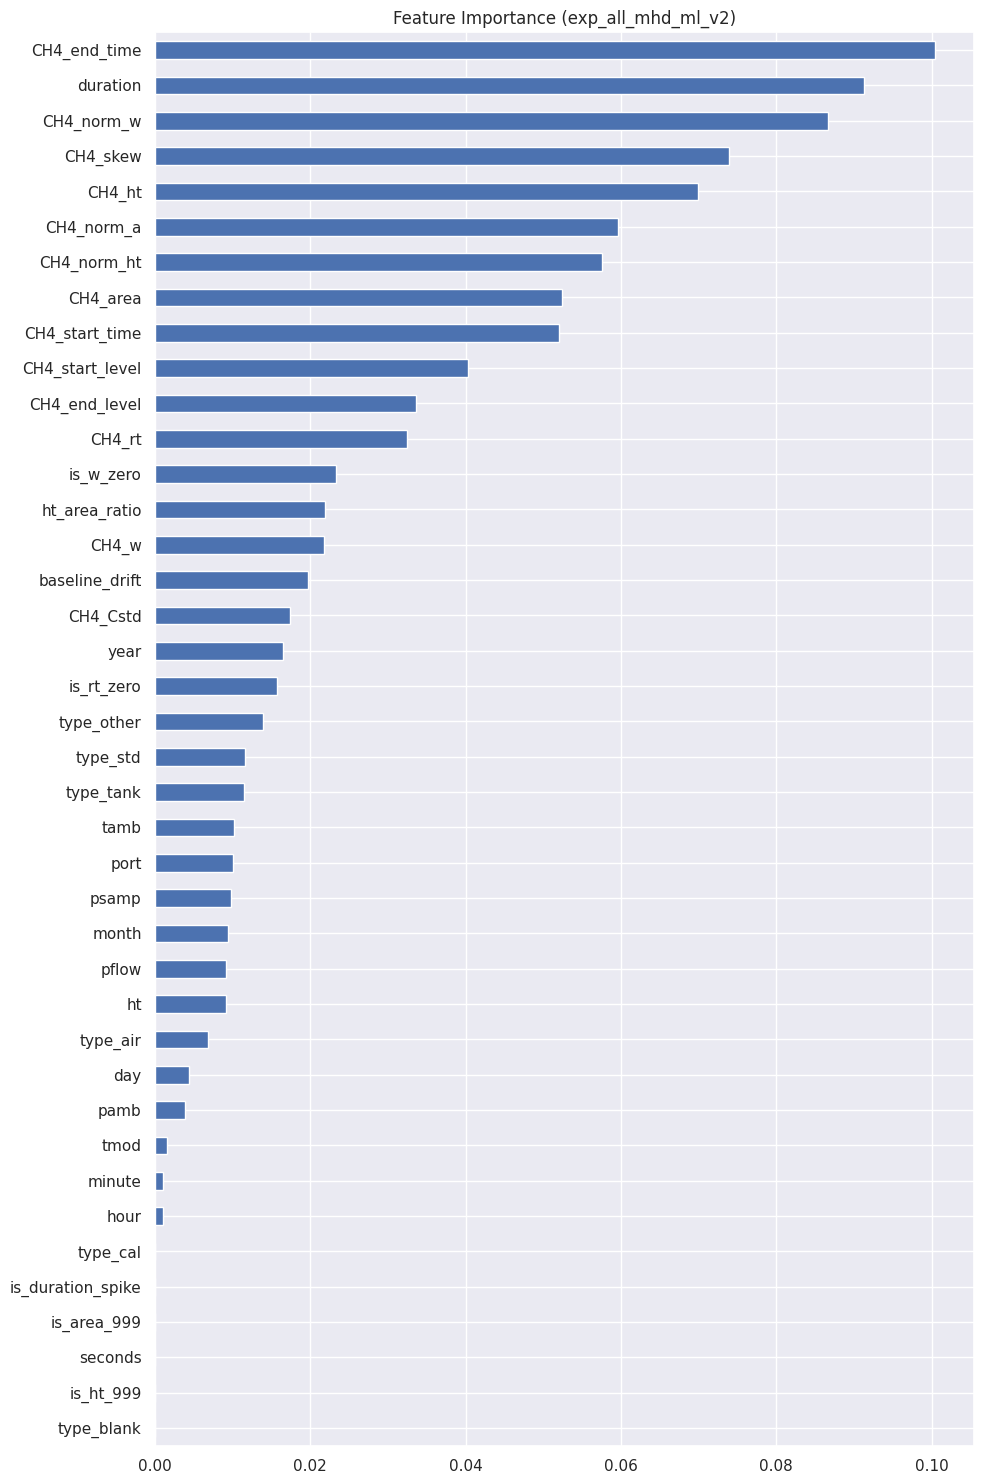

In [14]:
import mlflow
from sklearn.model_selection import train_test_split
from model import random_forest_model

for f, i  in feature_experiments.items() :
    X = data[i]
    y = data['label1']
    feature_cols = X.columns.tolist()
    split_idx = int(len(data)*0.8)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


    mlflow.set_experiment(f"{f}_mhd_ml_v2")
    print("Model training...")
    model = random_forest_model(
        X_train, y_train, X_test, y_test,
        feature_names=feature_cols,
        experiment_run_name=f'{f}_mhd_ml_v2',n_estimators=200, max_depth=12, n_jobs=-1
    )

# base on the results
-> doing more feature enginering

**Feature engineering**


In [15]:
# according to cols_all's results doing some feature engineering
data_updated_v1 = data.copy()

In [16]:
data_updated_v1 = data_updated_v1.sort_values("datetime")
data_updated_v1 = data_updated_v1.reset_index(drop=True)

In [17]:
data_updated_v1.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal,year,month,day,hour,minute,seconds
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,14,29,0
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,14,49,0
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,0.384554,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,15,9,0
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0.142279,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,15,29,0
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,18,0,0
5,940216,182000,air,10m,G-024,3,10,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216182000,1994-02-16 18:20:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,18,20,0
6,940216,184000,air,10m,G-024,3,10,40.01,33.20,NaN,846.3,760.57,NaN,760.5,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216184000,1994-02-16 18:40:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,18,40,0
7,940216,190000,air,10m,G-024,3,10,40.00,33.39,NaN,846.5,760.45,NaN,760.4,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216190000,1994-02-16 19:00:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,19,0,0
8,940216,192000,air,10m,G-024,3,10,40.00,33.61,NaN,846.6,760.34,NaN,760.3,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216192000,1994-02-16 19:20:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,19,20,0
9,940216,194000,air,10m,G-024,3,10,40.01,33.66,NaN,844.8,760.35,NaN,760.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216194000,1994-02-16 19:40:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,19,40,0


rolling mean

In [18]:
data_updated_v1['psamp_roll_mean_10'] = data_updated_v1['psamp'].rolling(window=5, min_periods=1).mean()
data_updated_v1['pamb_roll_mean_10'] = data_updated_v1['pamb'].rolling(window=5, min_periods=1).mean()
data_updated_v1['pflow_roll_mean_10'] = data_updated_v1['pflow'].rolling(window=10, min_periods=1).mean()
data_updated_v1['tmod_roll_mean_10'] = data_updated_v1['tmod'].rolling(window=10, min_periods=1).mean()

data_updated_v1['psamp_roll_mean_100'] = data_updated_v1['psamp'].rolling(window=5, min_periods=1).mean()
data_updated_v1['pamb_roll_mean_100'] = data_updated_v1['pamb'].rolling(window=5, min_periods=1).mean()
data_updated_v1['pflow_roll_mean_100'] = data_updated_v1['pflow'].rolling(window=10, min_periods=1).mean()
data_updated_v1['tmod_roll_mean_100'] = data_updated_v1['tmod'].rolling(window=10, min_periods=1).mean()



In [19]:
data_updated_v1.head()

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal,year,month,day,hour,minute,seconds,psamp_roll_mean_10,pamb_roll_mean_10,pflow_roll_mean_10,tmod_roll_mean_10,psamp_roll_mean_100,pamb_roll_mean_100,pflow_roll_mean_100,tmod_roll_mean_100
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,14,29,0,761.100000,761.100000,841.900000,40.000000,761.100000,761.100000,841.900000,40.000000
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,14,49,0,761.085000,761.150000,841.150000,40.000000,761.085000,761.150000,841.150000,40.000000
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,0.384554,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,15,9,0,761.053333,761.066667,840.566667,40.003333,761.053333,761.066667,840.566667,40.003333
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0.142279,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,15,29,0,761.030000,761.025000,840.325000,40.002500,761.030000,761.025000,840.325000,40.002500
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,18,0,0,760.968000,760.940000,841.340000,40.002000,760.968000,760.940000,841.340000,40.002000


In [20]:
# rolling std : catch unstable 
data_updated_v1['psamp_roll_std_10'] = data_updated_v1['psamp'].rolling(window=10, min_periods=1).std()
data_updated_v1['pamb_roll_std_10'] = data_updated_v1['pamb'].rolling(window=10, min_periods=1).std()
data_updated_v1['pflow_roll_std_10'] = data_updated_v1['pflow'].rolling(window=10, min_periods=1).std()

data_updated_v1['CH4_rt_roll_std_10'] = data_updated_v1['CH4_rt'].rolling(window=10, min_periods=1).std()


data_updated_v1['psamp_roll_std_100'] = data_updated_v1['psamp'].rolling(window=10, min_periods=1).std()
data_updated_v1['pamb_roll_std_100'] = data_updated_v1['pamb'].rolling(window=10, min_periods=1).std()
data_updated_v1['pflow_roll_std_100'] = data_updated_v1['pflow'].rolling(window=10, min_periods=1).std()

data_updated_v1['CH4_rt_roll_std_100'] = data_updated_v1['CH4_rt'].rolling(window=10, min_periods=1).std()



In [21]:
# diff : change compared to last moment
data_updated_v1['psamp_diff_1'] = data_updated_v1['psamp'].diff()
data_updated_v1['pflow_diff_1'] = data_updated_v1['pflow'].diff()
data_updated_v1['CH4_area_diff_1'] = data_updated_v1['CH4_area'].diff()

In [22]:
# lag
data_updated_v1['psamp_lag_1'] = data_updated_v1['psamp'].shift(1)
data_updated_v1['pflow_lag_1'] = data_updated_v1['pflow'].shift(1)

In [23]:
data_updated_v1.head(20)

,date,time,type,sample,standard,port,ht,tmod,tamb,lab_temp,pflow,psamp,ploop,pamb,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,CH4_Rl_ht,CH4_Rl_a,CH4_Rl,CH4_norm_ht,CH4_norm_a,CH4_norm_w,CH4_R_ht,CH4_R_a,CH4_R,CH4_C_ht,CH4_C_a,CH4_C,CH4_std_stdev,CH4_std_rep,CH4_Cstd,CH4_flag_ht,CH4_flag_a,CH4_flag,CH4_flag_p,CH4_flag_ht_bin,CH4_flag_a_bin,label1,datetime_str,datetime,is_ht_999,is_area_999,is_rt_zero,is_w_zero,duration,is_duration_spike,baseline_drift,ht_area_ratio,last_std_time,seconds_since_last_std,type_std,type_air,type_tank,type_blank,type_cal,type_other,last_cal_time,seconds_since_last_cal,year,month,day,hour,minute,seconds,psamp_roll_mean_10,pamb_roll_mean_10,pflow_roll_mean_10,tmod_roll_mean_10,psamp_roll_mean_100,pamb_roll_mean_100,pflow_roll_mean_100,tmod_roll_mean_100,psamp_roll_std_10,pamb_roll_std_10,pflow_roll_std_10,CH4_rt_roll_std_10,psamp_roll_std_100,pamb_roll_std_100,pflow_roll_std_100,CH4_rt_roll_std_100,psamp_diff_1,pflow_diff_1,CH4_area_diff_1,psamp_lag_1,pflow_lag_1
0,940216,142900,air,10m,G-024,3,10,40.00,32.27,NaN,841.9,761.10,NaN,761.1,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216142900,1994-02-16 14:29:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,14,29,0,761.100000,761.100000,841.900000,40.000000,761.100000,761.100000,841.900000,40.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,940216,144900,air,10m,G-024,3,10,40.00,32.48,NaN,840.4,761.07,NaN,761.2,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216144900,1994-02-16 14:49:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,14,49,0,761.085000,761.150000,841.150000,40.000000,761.085000,761.150000,841.150000,40.000000,0.021213,0.070711,1.060660,0.000000,0.021213,0.070711,1.060660,0.000000,-0.03,-1.5,0.0,761.10,841.9
2,940216,150900,air,10m,G-024,3,10,40.01,32.75,NaN,839.4,760.99,NaN,760.9,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216150900,1994-02-16 15:09:00,False,False,False,False,33.4,False,-34.0,0.384554,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,15,9,0,761.053333,761.066667,840.566667,40.003333,761.053333,761.066667,840.566667,40.003333,0.056862,0.152753,1.258306,63.393060,0.056862,0.152753,1.258306,63.393060,-0.08,-1.0,496440.0,761.07,840.4
3,940216,152900,air,10m,G-024,3,10,40.00,32.92,NaN,839.6,760.96,NaN,760.9,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,,,,,0,0,0,940216152900,1994-02-16 15:29:00,False,False,False,False,42.8,False,0.0,0.142279,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,15,29,0,761.030000,761.025000,840.325000,40.002500,761.030000,761.025000,840.325000,40.002500,0.065828,0.150000,1.135415,59.379542,0.065828,0.150000,1.135415,59.379542,-0.03,0.2,569542.0,760.99,839.4
4,940216,180000,air,10m,G-024,3,10,40.00,33.31,NaN,845.4,760.72,NaN,760.6,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216180000,1994-02-16 18:00:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,18,0,0,760.968000,760.940000,841.340000,40.002000,760.968000,760.940000,841.340000,40.002000,0.149900,0.230217,2.473459,56.282431,0.149900,0.230217,2.473459,56.282431,-0.24,5.8,-1065982.0,760.96,839.6
5,940216,182000,air,10m,G-024,3,10,40.01,33.10,NaN,846.2,760.60,NaN,760.7,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1692.489,F,F,,,1,1,1,940216182000,1994-02-16 18:20:00,False,False,True,True,0.0,False,0.0,NaN,NaN,NaN,0,1,0,0,0,0,NaN,NaN,1994,2,16,18,20,0,760.868000,760.860000,842.150000,40.003333,760.868000,760.860000,842.150000,40.003333,0.201362,0.228035,2.971700,53.040023,0.201362,0

In [24]:
cols_updated_v2 = [
    #'sample'	,'standard',	
    'port'	,'ht',
    'tmod'	,'tamb',
    'pflow', 'psamp',
    'pamb'	,
    'CH4_rt',	'CH4_w',	'CH4_ht'	,
    'CH4_area',	'CH4_skew'	,
    #'CH4_start_time',	'CH4_end_time'	,'CH4_start_level',	'CH4_end_level',
    #'CH4_Rl_ht',	'CH4_Rl_a',	'CH4_Rl',	
    #'CH4_norm_ht','CH4_norm_a',	'CH4_norm_w',
    #'CH4_R_ht','CH4_R_a', 'CH4_R'	,'
    #'CH4_C_ht'	,'CH4_C_a',	'CH4_C',	
    # std
    #'CH4_std_rep', 'CH4_std_rep'
    #'CH4_Cstd', 
    'is_ht_999', 'is_area_999', 'is_rt_zero', 'is_w_zero',
    'duration', 
    'is_duration_spike', 'baseline_drift', 'ht_area_ratio',
    'type_air', 'type_blank', 'type_cal', 'type_other', 'type_std', 'type_tank',
    #'year', 'month', 'day', 'hour', 'minute', 'seconds'
    'psamp_roll_mean_10', 'pamb_roll_mean_10', 'pflow_roll_std_10', 'tmod_roll_mean_10',
    'psamp_roll_std_10', 'pamb_roll_std_10', 'pflow_roll_std_10', 'CH4_rt_roll_std_10',
    
    'psamp_roll_mean_100', 'pamb_roll_mean_100', 'pflow_roll_std_100', 'tmod_roll_mean_100',
    'psamp_roll_std_100', 'pamb_roll_std_100', 'pflow_roll_std_100', 'CH4_rt_roll_std_100',
    'psamp_diff_1','pflow_diff_1', 'CH4_area_diff_1',
    'psamp_lag_1', 'pflow_lag_1'
]

In [25]:
feature_experiments = {
    'cols_updated_v2': cols_updated_v2
}

Model training...


2026/06/14 01:22:45 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
2026/06/14 01:22:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model training completed!
              precision    recall  f1-score   support

           0       0.94      0.99      0.96    146395
           1       0.84      0.42      0.56     17196

    accuracy                           0.93    163591
   macro avg       0.89      0.70      0.76    163591
weighted avg       0.93      0.93      0.92    163591



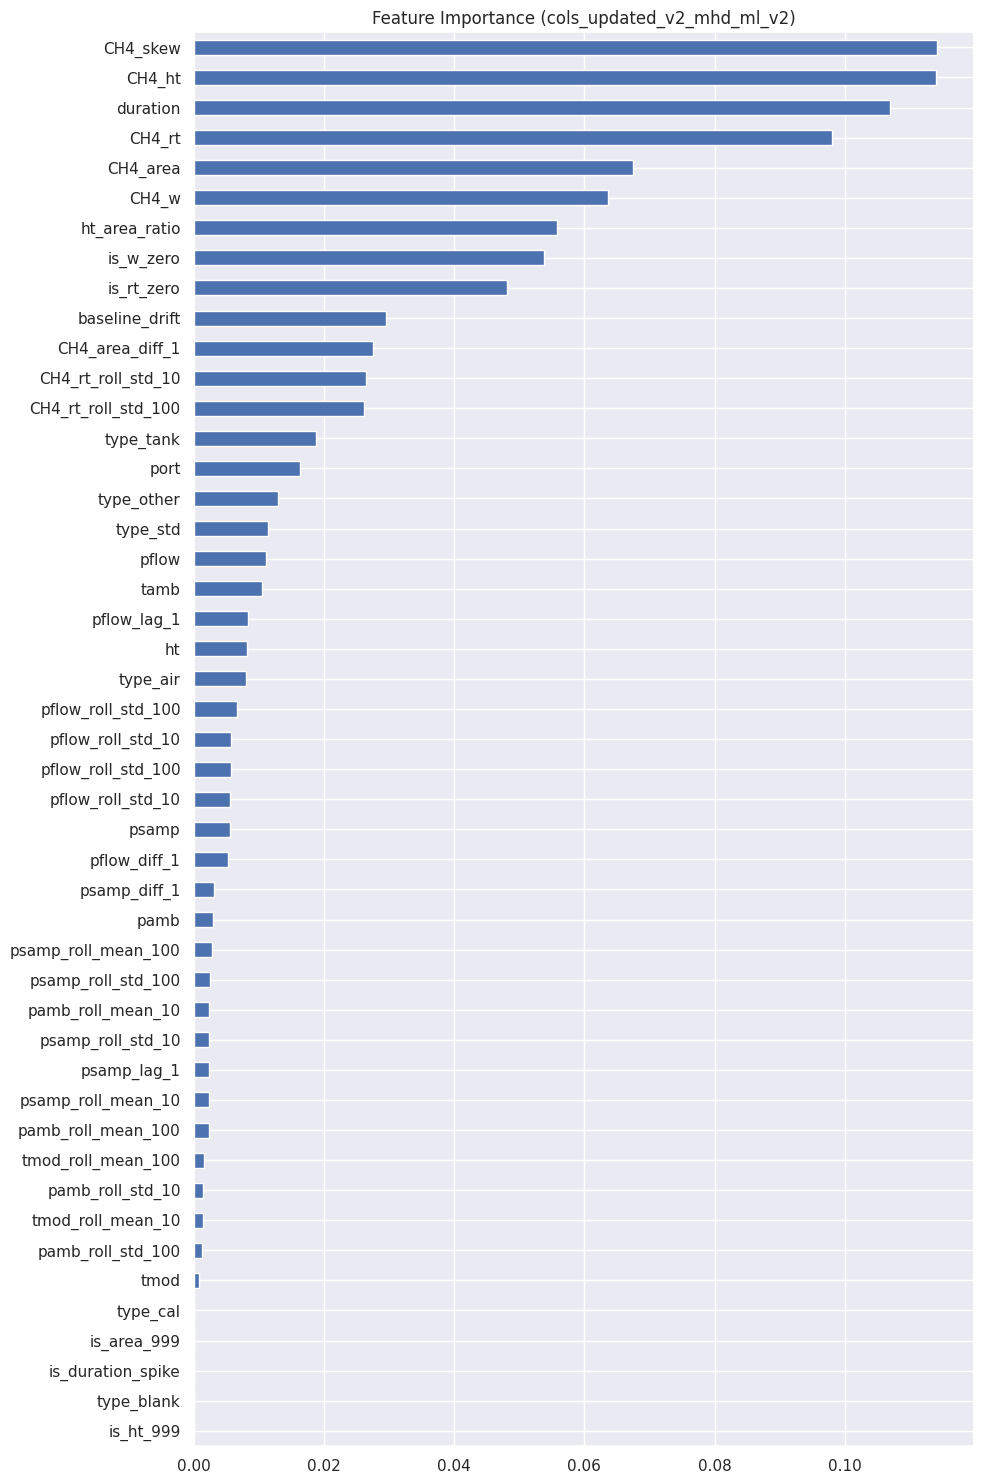

In [26]:
import mlflow
from sklearn.model_selection import train_test_split
from model import random_forest_model
for f, i in feature_experiments.items():
    X = data_updated_v1[i]
    y = data_updated_v1['label1']
    feature_cols = X.columns.tolist()
    split_idx = int(len(data_updated_v1)*0.8)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    #median_vals = X_train.median()


    mlflow.set_experiment(f"{f}_mhd_ml_v2")
    print("Model training...")
    model = random_forest_model(
        X_train, y_train, X_test, y_test,
        feature_names=feature_cols,
        experiment_run_name=f"{f}_mhd_ml_v2", n_estimators=200, max_depth=12, n_jobs=-1
    )



In [27]:
# try different threshold
y_proba = model.predict_proba(X_test)[:, 1]

In [28]:
y_proba[0:10]

array([0.0201383 , 0.01515946, 0.01994995, 0.01446257, 0.01873263,
       0.01356502, 0.01792101, 0.01224378, 0.01716762, 0.01349924])

In [29]:
from sklearn.metrics import recall_score, precision_score
thresholds = [0.5, 0.3, 0.1, 0.075, 0.05, 0.03, 0.025, 0.02, 0.015, 0.01]
for t in thresholds:
    y_pred = (y_proba>t).astype(int)
    print('threshold:', t, 'recall:', recall_score(y_test, y_pred), 'precision:', precision_score(y_test, y_pred))

threshold: 0.5 recall: 0.4186438706675971 precision: 0.8439624853458382
threshold: 0.3 recall: 0.5799023028611305 precision: 0.7990384615384616
threshold: 0.1 recall: 0.7040590835077926 precision: 0.712847385774847
threshold: 0.075 recall: 0.7196441032798325 precision: 0.6677999028654686
threshold: 0.05 recall: 0.7334845312863456 precision: 0.5850185528756957
threshold: 0.03 recall: 0.7594789485926959 precision: 0.4196118750803239
threshold: 0.025 recall: 0.7842521516631775 precision: 0.32782342359861927
threshold: 0.02 recall: 0.8362409862758781 precision: 0.22594786543689016
threshold: 0.015 recall: 0.9232379623168179 precision: 0.14511219779717563
threshold: 0.01 recall: 0.9887764596417772 precision: 0.11068868765908692


In [30]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold: {best_threshold}")
print(f'Best F1-score:{f1_scores[best_idx]:.4f}')
print(f'Precision"{precisions[best_idx]:.4f}", Recall:{recalls[best_idx]}')
print(best_idx)

Best Threshold: 0.2229851572624243
Best F1-score:0.7237
Precision"0.7928", Recall:0.6656780646662015
119738


**set threshold as 0.2229851572624243 to see how the model performs**


Model training...


2026/06/14 01:24:32 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
2026/06/14 01:24:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model training completed!
              precision    recall  f1-score   support

           0       0.96      0.98      0.97    146395
           1       0.79      0.67      0.72     17196

    accuracy                           0.95    163591
   macro avg       0.88      0.82      0.85    163591
weighted avg       0.94      0.95      0.94    163591



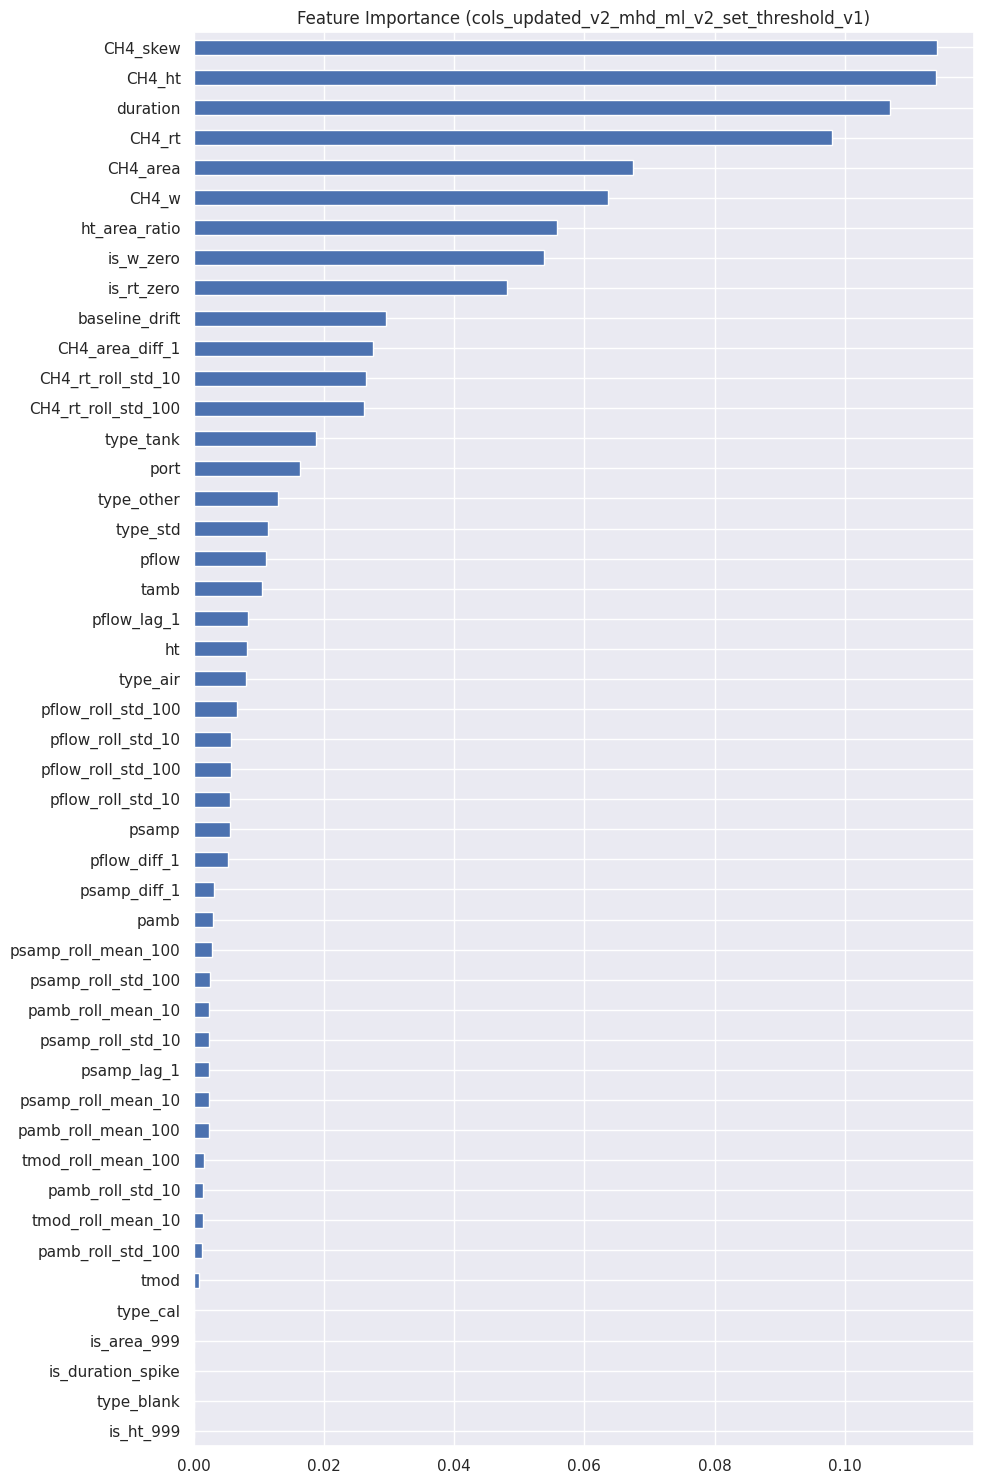

In [31]:
import mlflow
from sklearn.model_selection import train_test_split
from model import random_forest_model
for f, i in feature_experiments.items():
    X = data_updated_v1[i]
    y = data_updated_v1['label1']
    feature_cols = X.columns.tolist()
    split_idx = int(len(data_updated_v1)*0.8)

    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    #median_vals = X_train.median()


    mlflow.set_experiment(f"{f}_mhd_ml_v2")
    print("Model training...")
    model = random_forest_model(
        X_train, y_train, X_test, y_test,
        feature_names=feature_cols,
        experiment_run_name=f"{f}_mhd_ml_v2_set_threshold_v1", n_estimators=200, max_depth=12, n_jobs=-1, threshold =0.2229851572624243
    )


**traing model based on type**

# ML